# Federated normative modeling

In multi-site neuroimaging studies, data often cannot leave the hospital or institution where it was collected, due to privacy regulations such as GDPR. **Federated learning (FL)** addresses this constraint: each site trains a model locally and shares only the trained model; never the raw data.

This tutorial demonstrates a FL workflow for normative modeling using the PCNtoolkit. For more details you can read the paper below:

> Kia SM, Huijsdens H, Rutherford S, de Boer A, Dinga R, Wolfers T, et al. (2022)  
> *Closing the life-cycle of normative modeling using federated hierarchical Bayesian regression.*  
> PLoS ONE 17(12): e0278776. https://doi.org/10.1371/journal.pone.0278776

### What we will do

**Part 1: Classic normative modelling workflow**
1. **Fit a model** on all data together (let's call it *baseline model* as later we will compare it with the aggregated model produced from the FL workflow)

**Part 2: FL with `extend()`**

2. **Split** the data into a large central dataset and two smaller ones
3. **Fit a central model** on the central dataset only
4. **Extend** the central model to each of the two smaller datasets
5. **Merge** the central model and the two extended models into a single global model
6. **Compare** the extended federated model to the baseline model

**Part 3: FL with `transfer()`**

7. **Transfer** the central model to each of the two smaller datasets
8. **Compare** the aggregated model (with `transfer()`) to the aggregated model (with `extend()`)

### Key functions

| Function | Role |
|---|---|
| `NormativeModel.fit()` | Fit the central model |
| `NormativeModel.extend()` | Refit the central model with data from the smaller model + synthetic data (generated from the central model) |
| `NormativeModel.transfer()` | Transfer the central model's priors to the smaller dataset |
| `NormativeModel.merge()` | Aggregate central + extended/transferred models |
| `NormativeModel.predict()` | Evaluate the final aggregated model |

### Imports

In [30]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormalLikelihood,
    NormativeModel,
    NormData,
    load_fcon1000,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
)

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

## Load data

We use the [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html) dataset that is included in PCNtoolkit, which contains resting state fMRI from 1078 subjects across 23 sites. We select a single response variable (`WM-hypointensities`) to keep the tutorial fast.

In [31]:
# Download the dataset
norm_data: NormData = load_fcon1000()

# Select only the white matter hypointensities feature
features_to_model = ["WM-hypointensities"]
norm_data = norm_data.sel(
    {"response_vars": features_to_model}
)

# Show all available sites
all_sites = np.unique(
    norm_data.batch_effects.sel(
        batch_effect_dims="site"
    ).values
)
print(
    f"Total sites: {len(all_sites)}"
)
print(f"Sites: {all_sites}")

Total sites: 23
Sites: ['AnnArbor_a' 'AnnArbor_b' 'Atlanta' 'Baltimore' 'Bangor' 'Beijing_Zang'
 'Berlin_Margulies' 'Cambridge_Buckner' 'Cleveland' 'ICBM' 'Leiden_2180'
 'Leiden_2200' 'Milwaukee_b' 'Munchen' 'NewYork_a' 'NewYork_a_ADHD'
 'Newark' 'Oulu' 'Oxford' 'PaloAlto' 'Pittsburgh' 'Queensland'
 'SaintLouis']


## Split data

We split the data into:
- A large central dataset (19 sites)
- Two smaller datasets (each dataset has 2 sites) 

In a FL scenario the large model would be owned by a central location (e.g., a hospital in the Netherlands) and the smaller ones by locations 1 and 2 (e.g, a hospital in France and in the USA). All these locations don't want to share their data due to privacy. For this reason, they use the FL workflow.

![alt text](fl-graph.png)

Figure 1: Adopted from Fed-BioMed toolbox (for more info see: https://fedbiomed.org/)

In [32]:
# Pick 2 sites for each remote location
location1_sites = list(all_sites[:2])
location2_sites = list(all_sites[2:4])
print(
    f"Location 1 sites: {location1_sites}"
)
print(
    f"Location 2 sites: {location2_sites}"
)

# Split off location 1
location1_data, remaining = (
    norm_data.batch_effects_split(
        {"site": location1_sites},
        names=("location1", "remaining"),
    )
)

# Split off location 2 from the remainder
location2_data, central_data = (
    remaining.batch_effects_split(
        {"site": location2_sites},
        names=("location2", "central"),
    )
)

# Create train/test splits for each location
central_train, central_test = (
    central_data.train_test_split()
)
location1_train, location1_test = (
    location1_data.train_test_split()
)
location2_train, location2_test = (
    location2_data.train_test_split()
)

# Global train/test for the baseline model
train_all, test_all = (
    norm_data.train_test_split()
)

print(
    f"\nCentral: "
    f"{central_train.X.shape[0]} train, "
    f"{central_test.X.shape[0]} test"
)
print(
    f"Location 1: "
    f"{location1_train.X.shape[0]} train, "
    f"{location1_test.X.shape[0]} test"
)
print(
    f"Location 2: "
    f"{location2_train.X.shape[0]} train, "
    f"{location2_test.X.shape[0]} test"
)
print(
    f"All data: "
    f"{train_all.X.shape[0]} train, "
    f"{test_all.X.shape[0]} test"
)

Location 1 sites: [np.str_('AnnArbor_a'), np.str_('AnnArbor_b')]
Location 2 sites: [np.str_('Atlanta'), np.str_('Baltimore')]

Central: 776 train, 195 test
Location 1: 44 train, 12 test
Location 2: 40 train, 11 test
All data: 862 train, 216 test


## Visualize the data

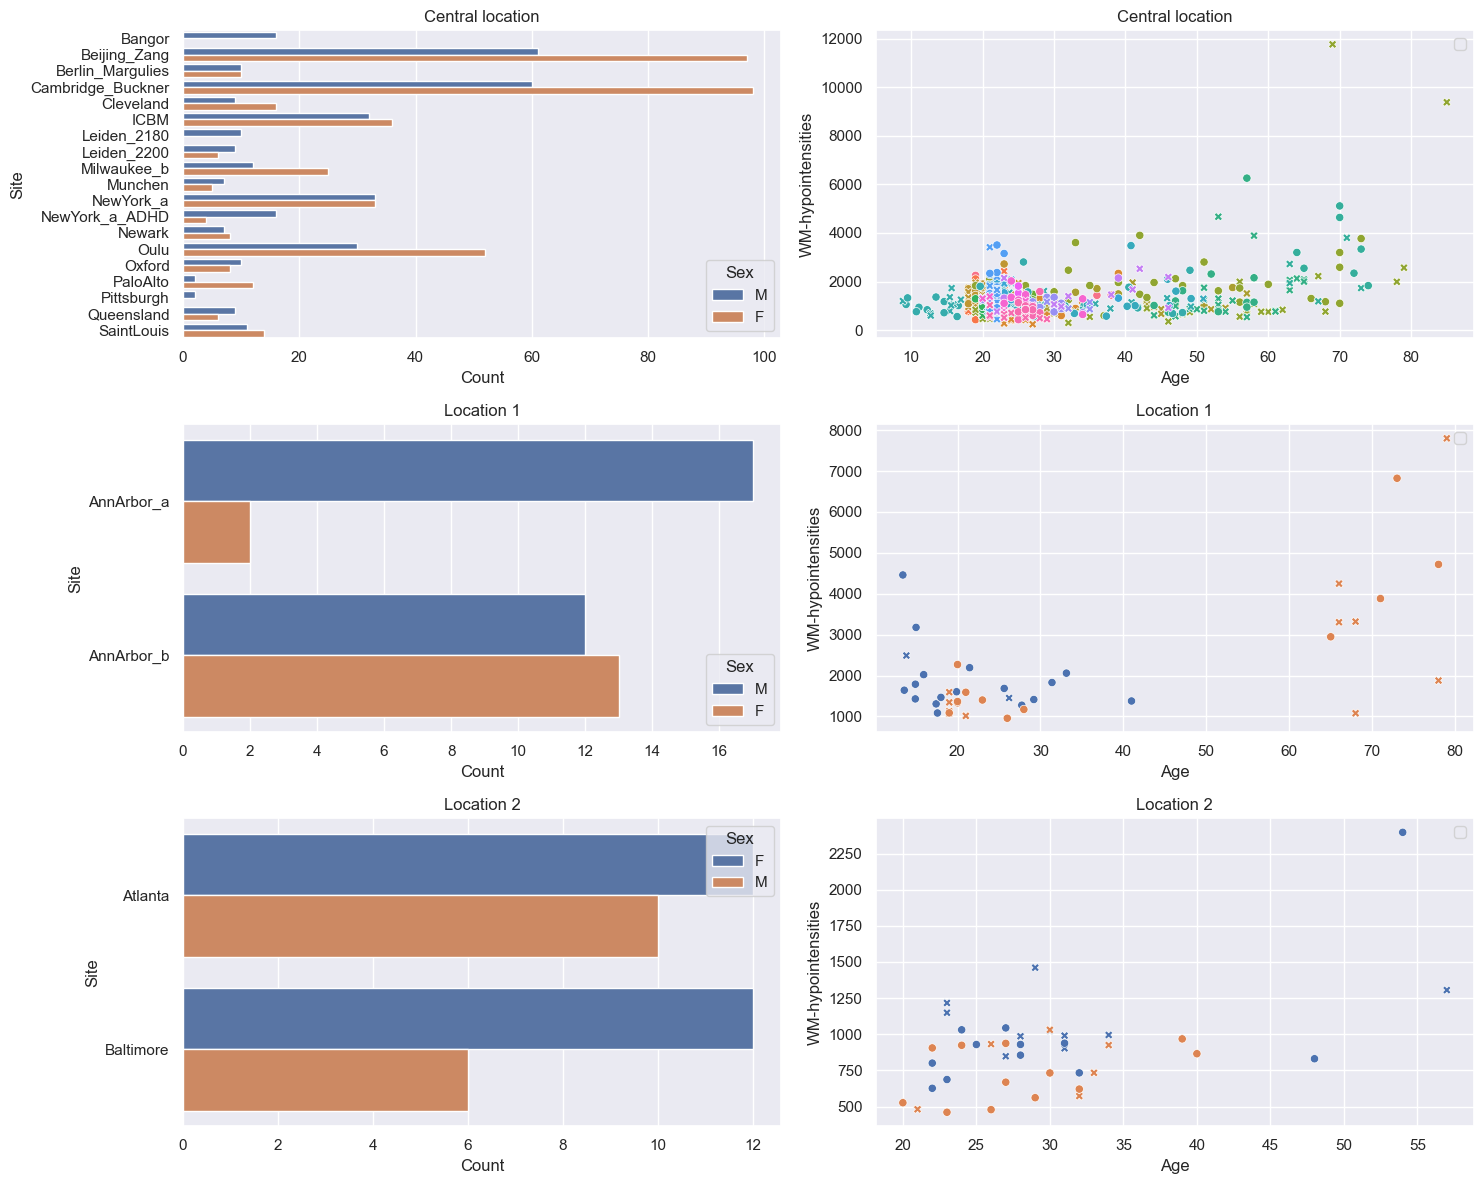

In [33]:
feature = features_to_model[0]
datasets = {
    "Central location": central_train,
    "Location 1": location1_train,
    "Location 2": location2_train,
}

fig, axes = plt.subplots(
    3, 2, figsize=(15, 12)
)

# for every dataset
for i, (name, data) in enumerate(
    datasets.items()
):
    df = data.to_dataframe()
    # Count plot
    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[i, 0],
        orient="h",
    )
    axes[i, 0].legend(title="Sex")
    axes[i, 0].set_title(
        f"{name}"
    )
    axes[i, 0].set_xlabel("Count")
    axes[i, 0].set_ylabel("Site")

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[i, 1],
    )
    axes[i, 1].legend([], [])
    axes[i, 1].set_title(
        f"{name}"
    )
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

## Configure the HBR model

We define a shared model configuration that will be used for **all** models (baseline, central, transferred, and aggregated). This ensures a fair comparison. We use a Normal likelihood HBR with B-spline basis functions and hierarchical priors on the intercept.

For a detailed explanation of this configuration, see *Tutorial 03 - HBR with Normal Likelihood*.

In [34]:
# Prior for the mean function (mu)
mu = make_prior(
    linear=True,
    slope=make_prior(
        dist_name="Normal",
        dist_params=(0.0, 5.0),
    ),
    intercept=make_prior(
        random=True,
        mu=make_prior(
            dist_name="Normal",
            dist_params=(0.0, 1.0),
        ),
        sigma=make_prior(
            dist_name="Gamma",
            dist_params=(1.0, 1.0),
        ),
    ),
    basis_function=BsplineBasisFunction(
        basis_column=0, nknots=5, degree=3
    ),
)

# Prior for the noise function (sigma)
sigma = make_prior(
    linear=True,
    slope=make_prior(
        dist_name="Normal",
        dist_params=(0.0, 2.0),
    ),
    intercept=make_prior(
        dist_name="Normal",
        dist_params=(1.0, 1.0),
    ),
    basis_function=BsplineBasisFunction(
        basis_column=0, nknots=5, degree=3
    ),
    mapping="softplus",
    mapping_params=(0.0, 2.0),
)

likelihood = NormalLikelihood(mu, sigma)

template_hbr = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=likelihood,
)

---

## Part 1: Baseline model

In a non-federated scenario, we would pool all the data from every site into a single dataset and train one model.

In [35]:
baseline_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir=(
        "resources/federated/baseline"
    ),
    inscaler="standardize",
    outscaler="standardize",
)

test_all = baseline_model.fit_predict(
    train_all, test_all
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,33,0.12,31
,2000,25,0.13,63
,2000,8,0.11,95
,2000,4,0.12,31


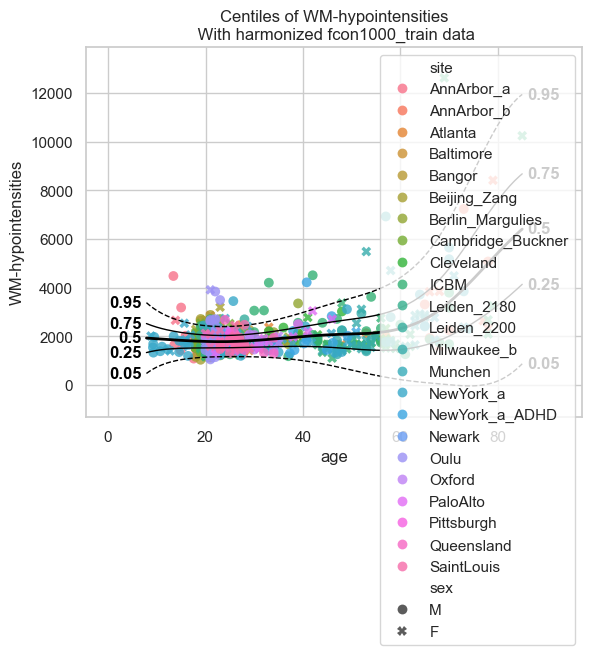

In [36]:
# Visualize baseline model centiles
plot_centiles_advanced(
    baseline_model,
    scatter_data=train_all,
    batch_effects="all",
)

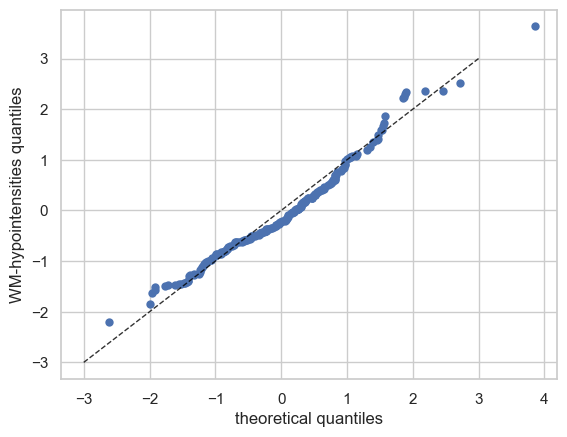

In [37]:
# QQ plot of baseline model
plot_qq(test_all, plot_id_line=True)

In [38]:
# Evaluation metrics for baseline model
baseline_stats = test_all.get_statistics_df()
baseline_stats

statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
WM-hypointensities,0.366316,0.037963,0.341545,-0.325879,0.79339,0.363138,482.996963,0.490014,1.905315e-14,0.636862,0.963949


---

## Part 2: FL with `extend()`

Now we simulate the FL scenario. The central location **does not have access** to the data at Location 1 and Location 2. Only model parameters are exchanged.

### Step 1: Train the central model

The central location trains an HBR model using only its own 19 sites.

In [39]:
central_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=False,
    evaluate_model=True,
    saveresults=False,
    saveplots=False,
    save_dir=(
        "resources/federated/central"
    ),
    inscaler="standardize",
    outscaler="standardize",
)

central_model.fit(central_train)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,22,0.12,255
,2000,17,0.14,31
,2000,10,0.13,31
,2000,88,0.14,31


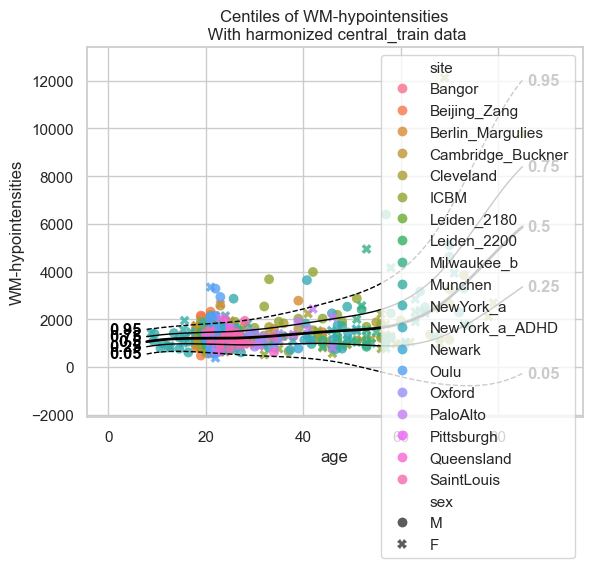

In [40]:
# Centile curves for the central model
plot_centiles_advanced(
    central_model,
    scatter_data=central_train,
    batch_effects="all",
)

### Step 2: Extend the central model to remote locations

Each remote location receives the central model file and calls `extend()` locally using its own private data.

`extend()` synthesizes data from the central model's learned distribution, merges it with the real local data, and refits a full model.

**No real data is exchanged only model parameters.**

In [41]:
# Location 1 extends the central model
# with their private data.
extended_1 = central_model.extend(
    location1_train,
    save_dir=(
        "resources/federated/extended_1"
    ),
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,20,0.11,255
,2000,19,0.10,63
,2000,19,0.12,127
,2000,19,0.11,63


In [42]:
# Location 2 extends the central model
# independently.
extended_2 = central_model.extend(
    location2_train,
    save_dir=(
        "resources/federated/extended_2"
    ),
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,4,0.10,63
,2000,20,0.10,223
,2000,14,0.10,127
,2000,15,0.11,63


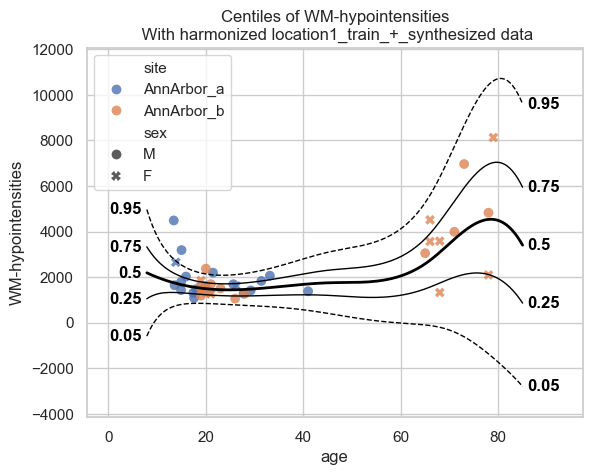

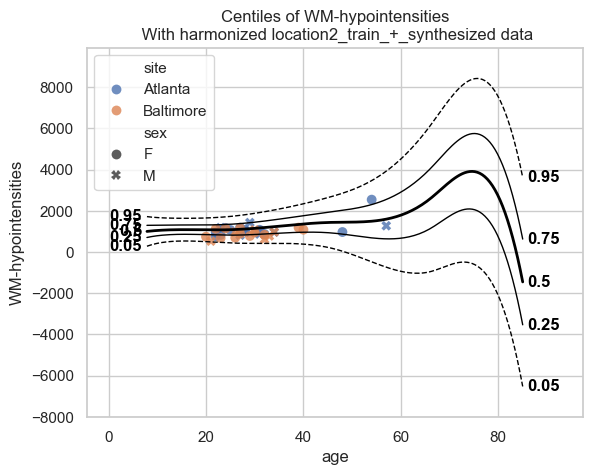

In [43]:
# Visualize the extended models
plot_centiles_advanced(
    extended_1,
    scatter_data=location1_train,
    batch_effects="all",
)

plot_centiles_advanced(
    extended_2,
    scatter_data=location2_train,
    batch_effects="all",
)

Each extended model knows about both the central sites (via synthetic data) and its own local sites.

### Step 3: Merge extended models

Merge the central model with both extended models using `NormativeModel.merge()`.

Under the hood, `merge()` does the following:
1. Calls `synthesize()` on each model to generate synthetic data from its learned distribution
2. Pools all synthetic datasets together
3. Refits a single global model on the combined synthetic data

**No real data is exchanged only model parameters.**

In [44]:
# Merge central + both extended models
aggregated_model_with_extend = NormativeModel.merge(
    save_dir=(
        "resources/federated/merged_extend"
    ),
    models=[
        central_model,
        extended_1,
        extended_2,
    ],
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,21,0.12,63
,2000,18,0.12,31
,2000,16,0.12,31
,2000,16,0.13,31


### Step 4: Predict with the aggregated model

The aggregated model now covers all 23 sites. We can predict on the full test set.

In [45]:
test_all_extended = test_all.copy(deep=True)
aggregated_model_with_extend.predict(
    test_all_extended
)

<xarray.NormData> Size: 52kB
Dimensions:            (observations: 216, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U18 72B 'WM-hypointensities'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 2kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 2kB 0.5074 ... -...
    baseline_logp      (observations, response_vars) float64 2kB -3.726 ... -...
    logp               (observations, response_vars) float64 2kB -1.848 ... -...
    Yhat               (observations, response_vars) float64 2kB 1.86e+03 ......
    statistics         (response_vars, statistic) float64 88B 0.3756 ... 0.9536
    centiles           (centile, observations, response_vars) float64 9kB -93...
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

---

## Evaluation: Baseline vs. Aggregated model


### Centile curves

=== baseline model ===


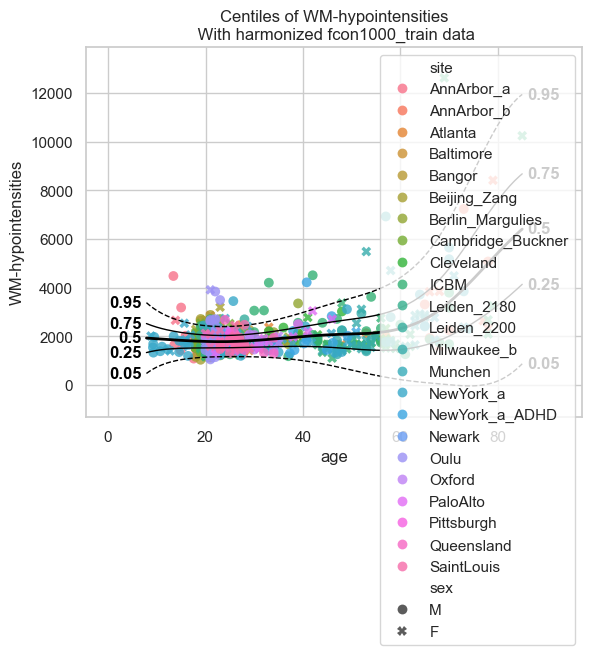


=== Federated (extend) ===


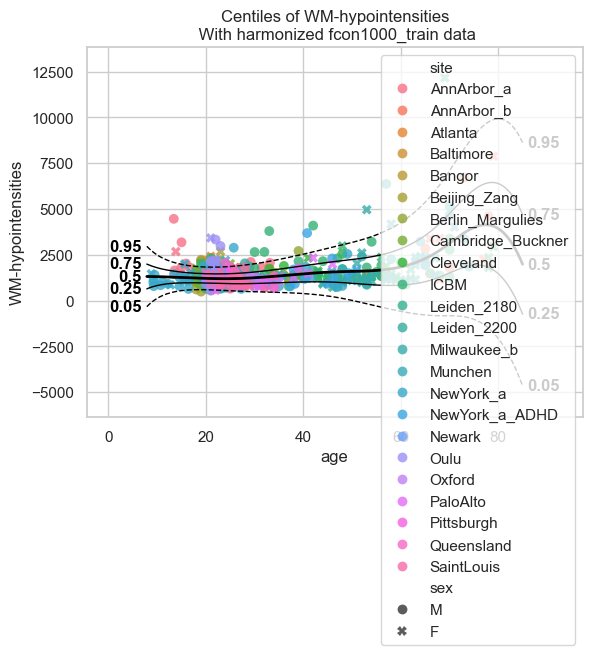

In [46]:
# baseline model centiles
print("=== baseline model ===")
plot_centiles_advanced(
    baseline_model,
    scatter_data=train_all,
    batch_effects="all",
)

# Federated model centiles (extend)
print("\n=== Federated (extend) ===")
plot_centiles_advanced(
    aggregated_model_with_extend,
    scatter_data=train_all,
    batch_effects="all",
)

### QQ plots

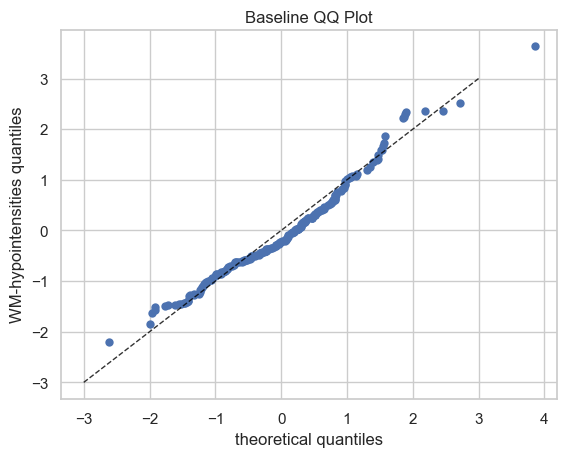

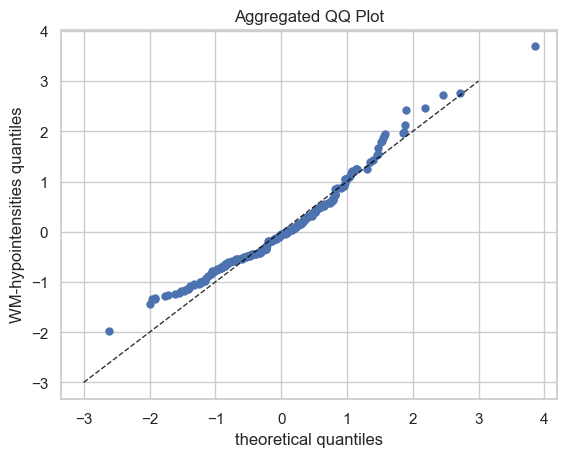

In [53]:

# baseline QQ plot
plt.title("Baseline QQ Plot")
plot_qq(test_all, plot_id_line=True)

# Aggregated QQ plot
plt.title("Aggregated QQ Plot")
plot_qq(test_all_extended, plot_id_line=True)


### Evaluation metrics

Compare key metrics side by side.

In [48]:
# Collect metrics from both models
baseline_stats = (
    test_all.get_statistics_df()
)
extend_stats = (
    test_all_extended.get_statistics_df()
)

# Label each with a MultiIndex
baseline_stats.index = (
    pd.MultiIndex.from_tuples(
        [
            ("baseline", idx)
            for idx in baseline_stats.index
        ]
    )
)
extend_stats.index = (
    pd.MultiIndex.from_tuples(
        [
            ("Federated (extend)", idx)
            for idx in extend_stats.index
        ]
    )
)

comparison_early = pd.concat(
    [baseline_stats, extend_stats]
)
comparison_early

,statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
baseline,WM-hypointensities,0.366316,0.037963,0.341545,-0.325879,0.793390,0.363138,482.996963,0.490014,1.905315e-14,0.636862,0.963949
Federated (extend),WM-hypointensities,0.375633,0.038889,0.326389,-0.332083,0.852719,0.375504,478.284642,0.485657,3.491174e-14,0.624496,0.953557


---

## Part 3: FL with `transfer()`

We now repeat the federated workflow, but using `transfer()` instead of `extend()`.

**Key difference:**
- `extend()` synthesizes central data, merges it with local data, and refits the full model — more expressive but less private
- `transfer()` adapts only the batch-effect intercepts — faster and more privacy-preserving

### Step 1: Transfer to both locations

In [49]:
# Location 1 adapts the central model
# via transfer (intercept-only adaptation)
transferred_1 = central_model.transfer(
    location1_train,
    save_dir=(
        "resources/federated/transferred_1"
    ),
)

# Location 2 adapts independently
transferred_2 = central_model.transfer(
    location2_train,
    save_dir=(
        "resources/federated/transferred_2"
    ),
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,2,0.29,15
,2000,1,0.30,15
,2000,1,0.30,15
,2000,0,0.30,15


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,5,0.22,31
,2000,0,0.22,63
,2000,1,0.21,63
,2000,0,0.23,15


Each transferred model only adapts the batch-effect intercepts from the central model to account for local site differences. The covariate relationship (age effect) stays unchanged.

### Step 2: Merge transferred models and predict

In [50]:
# Merge central + both transferred models
aggregated_model_with_transfer = NormativeModel.merge(
    save_dir="resources/federated/merged_transfer",
    models=[
        central_model,
        transferred_1,
        transferred_2,
    ],
)

# Predict on the full test set
test_all_federated = test_all.copy(deep=True)
aggregated_model_with_transfer.predict(test_all_federated)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,7,0.11,127
,2000,3,0.11,63
,2000,19,0.13,159
,2000,20,0.12,191


<xarray.NormData> Size: 52kB
Dimensions:            (observations: 216, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U18 72B 'WM-hypointensities'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 2kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 2kB 0.3761 ... -...
    baseline_logp      (observations, response_vars) float64 2kB -3.726 ... -...
    logp               (observations, response_vars) float64 2kB -1.564 ... -...
    Yhat               (observations, response_vars) float64 2kB 2.211e+03 .....
    statistics         (response_vars, statistic) float64 88B 0.3019 ... 0.9468
    centiles           (centile, observations, response_vars) float64 9kB -21...
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

---

## Final comparison: Transfer vs. Extend vs. baseline

We now compare all three models:
- **baseline** — trained on all data pooled (gold standard)
- **Federated (extend)** — remote sites used `extend()` (more expressive)
- **Federated (transfer)** — remote sites used `transfer()` (privacy-preserving)

### Centile curves

=== baseline model ===


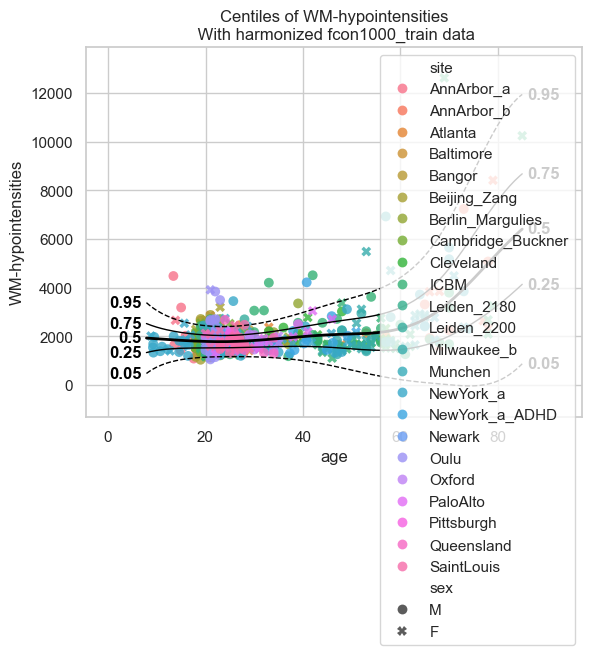


=== Federated (extend) ===


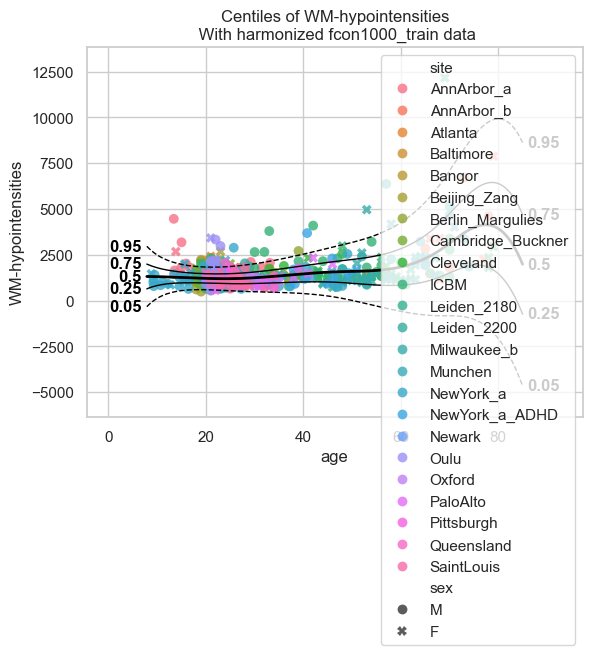


=== Federated (transfer) ===


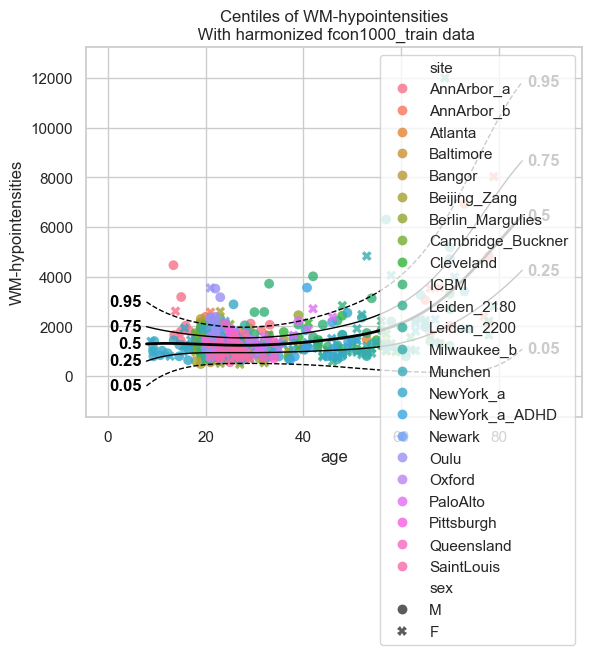

In [51]:
# baseline model centiles
print("=== baseline model ===")
plot_centiles_advanced(
    baseline_model,
    scatter_data=train_all,
    batch_effects="all",
)

# Federated model centiles (extend)
print("\n=== Federated (extend) ===")
plot_centiles_advanced(
    aggregated_model_with_extend,
    scatter_data=train_all,
    batch_effects="all",
)

# Federated model centiles (transfer)
print("\n=== Federated (transfer) ===")
plot_centiles_advanced(
    aggregated_model_with_transfer,
    scatter_data=train_all,
    batch_effects="all",
)

### QQ plots and evaluation metrics

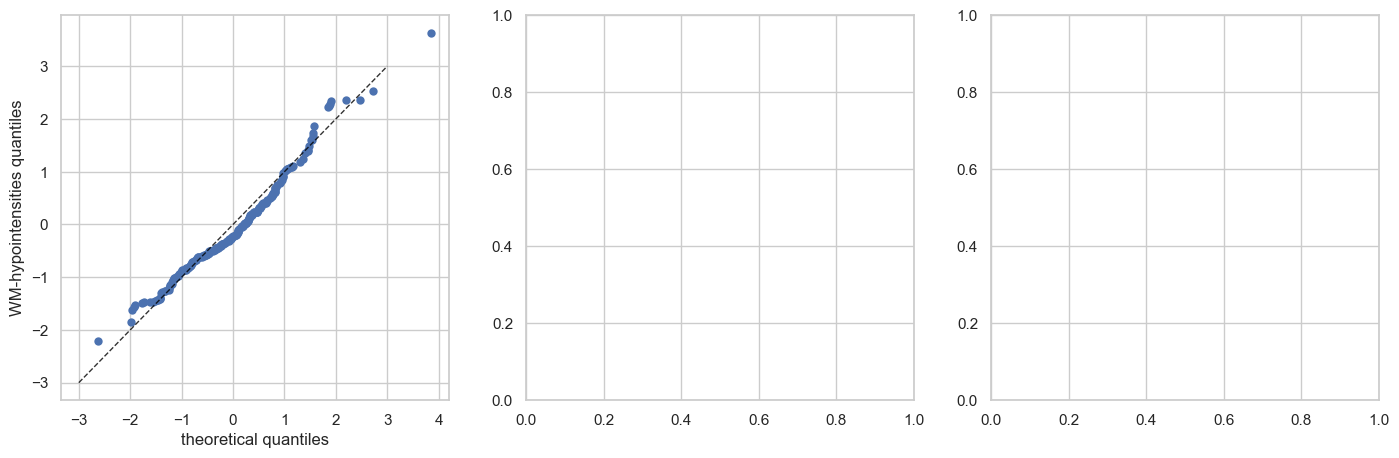

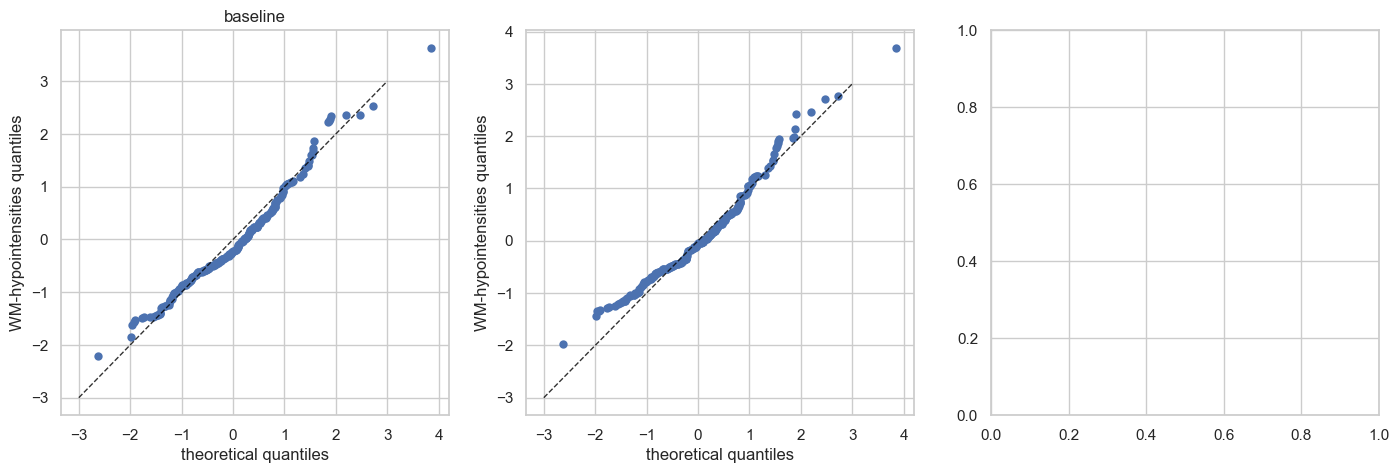

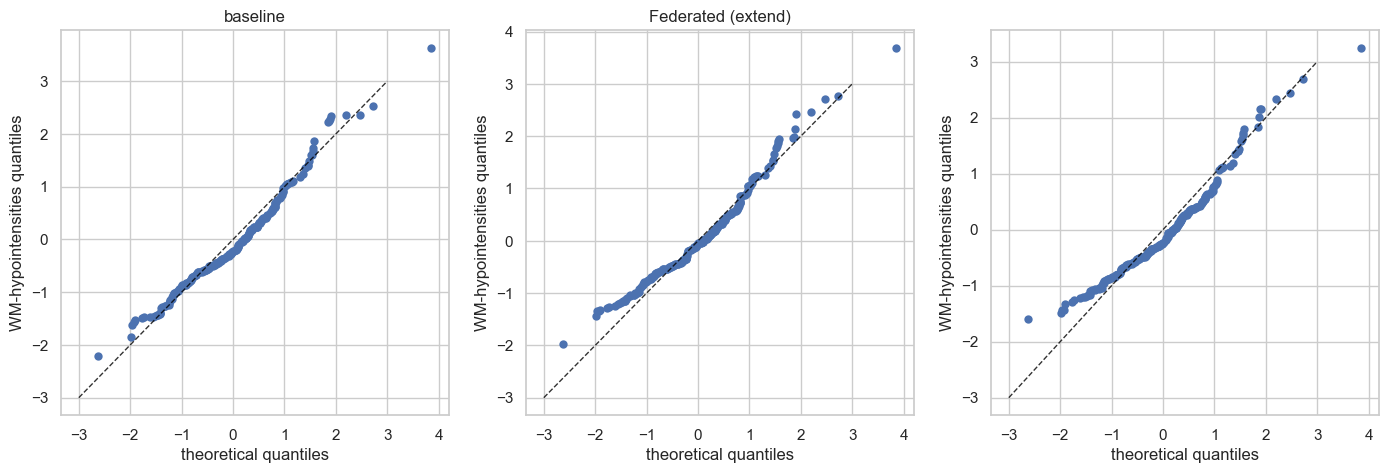

<Figure size 640x480 with 0 Axes>

,statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
baseline,WM-hypointensities,0.366316,0.037963,0.341545,-0.325879,0.793390,0.363138,482.996963,0.490014,1.905315e-14,0.636862,0.963949
Federated (extend),WM-hypointensities,0.375633,0.038889,0.326389,-0.332083,0.852719,0.375504,478.284642,0.485657,3.491174e-14,0.624496,0.953557
Federated (transfer),WM-hypointensities,0.301919,0.048148,0.374153,-0.261016,0.923786,0.297260,507.363402,0.396773,1.470344e-09,0.702740,0.946777


In [52]:
# QQ plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

plt.sca(axes[0])
plot_qq(test_all, plot_id_line=True)
axes[0].set_title("baseline")

plt.sca(axes[1])
plot_qq(
    test_all_extended, plot_id_line=True
)
axes[1].set_title("Federated (extend)")

plt.sca(axes[2])
plot_qq(
    test_all_federated, plot_id_line=True
)
axes[2].set_title("Federated (transfer)")

plt.tight_layout()
plt.show()

# Evaluation metrics for all three
baseline_stats = (
    test_all.get_statistics_df()
)
extend_stats = (
    test_all_extended.get_statistics_df()
)
transfer_stats = (
    test_all_federated.get_statistics_df()
)

# Label each with a MultiIndex
baseline_stats.index = (
    pd.MultiIndex.from_tuples(
        [
            ("baseline", idx)
            for idx in baseline_stats.index
        ]
    )
)
extend_stats.index = (
    pd.MultiIndex.from_tuples(
        [
            ("Federated (extend)", idx)
            for idx in extend_stats.index
        ]
    )
)
transfer_stats.index = (
    pd.MultiIndex.from_tuples(
        [
            ("Federated (transfer)", idx)
            for idx in transfer_stats.index
        ]
    )
)

comparison = pd.concat(
    [
        baseline_stats,
        extend_stats,
        transfer_stats,
    ]
)
comparison

## Conclusion

Both federated approaches — `extend + merge` and `transfer + merge` — produce models that approximate the baseline model, all without sharing raw data between sites.

### `extend()` vs `transfer()` — when to use which

| | `extend()` | `transfer()` |
|---|---|---|
| **What it does** | Synthesizes central data, merges with local data, refits entire model | Adapts only the batch-effect intercepts |
| **Privacy** | Lower — the extended model has seen real local data mixed with synthetic | Higher — only intercept parameters encode local information |
| **Expressiveness** | Full — can learn a new covariate relationship from the combined data | Limited — cannot change the learned covariate relationship |
| **Speed** | Slower — full model refit | Fast — only optimizes intercepts |
| **Best when** | Local sites differ substantially from central; accuracy is the priority | Privacy is paramount; local sites are similar to central |

### Key takeaways

- **Privacy preserved in both**: Raw data never left any site. Only model files were exchanged.
- **`transfer()` is more private**: It adapts only intercepts, minimizing information leakage.
- **`extend()` may be more accurate**: By refitting the full model on synthetic + local data, it can better capture local patterns.
- **`merge()` for aggregation**: In both approaches, the central hub merges all models using synthesis-based aggregation.
- **Compare metrics**: Check the evaluation tables above to see which approach works better for your data.

### Practical considerations

- **More sites, more rounds**: The same pattern scales to any number of remote locations.
- **Communication overhead**: Only model files are transferred (typically a few MB per response variable).
- **Within-site sample size**: Both transfer and extend work best when each remote site has enough observations.